# `SoftHarmonic` bond & `SoftHarmonicAngle` — emergent behaviour

These forces are **harmonic near equilibrium but saturate in the tail** (per type):

* `tail="linear"` (Huber) — harmonic up to a crossover `x_c`, then a **constant**
  restoring force/torque `k·x_c`.
* `tail="flat"` — the restoring force/torque decays smoothly to **zero** at `x_c`
  and stays zero beyond it.

The potential shapes are in [`../energy_landscapes.ipynb`](../energy_landscapes.ipynb).
This notebook instead shows three things you **cannot read off the potential** — each
measured from a real simulation and contrasted with the standard harmonic force:

1. **Kinkable filament** (flat angle) — same local stiffness, but thermal *kinks*
   appear, giving a non-Gaussian bending distribution and a much shorter persistence
   length.
2. **Breakable vs ductile bond** (flat vs linear) — a pulled chain fails *brittly*
   (flat) or *yields* ductilely (linear), while harmonic is elastic.
3. **Timestep stability** (linear bond) — the force cap removes the stiff timescale of
   taut bonds, so integration survives much larger `dt`.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import hoomd
from hoomd import align_angle

dev = hoomd.device.auto_select()
print("HOOMD", hoomd.version.version, "| device:", type(dev).__name__,
      "| precision", hoomd.version.floating_point_precision)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "lines.linewidth": 2.0})


def positions_by_tag(sim):
    """Positions ordered by particle tag (HOOMD reorders internally)."""
    with sim.state.cpu_local_snapshot as ss:
        tags = np.array(ss.particles.tag[:]); pos = np.array(ss.particles.position[:])
    return pos[np.argsort(tags)]

HOOMD 6.1.1 | device: GPU | precision (64, 32)


## 1. Kinkable filament (flat angle)

A long (N=500) stiff semiflexible chain, started from a **randomly folded** conformation
(a persistent / worm-like random walk from
`polykit.generators.initial_conformations.create_constrained_random_walk`, with an inline
fallback) and briefly warmed up, then run with a **harmonic** angle vs a **flat-tail**
angle of the *same* stiffness `k` (`t0 = π`). Near equilibrium both are identical, so the
local stiffness matches (and the harmonic chain recovers its expected `Lp ≈ k`). But
bending past `x_c` costs the flat tail only `k·x_c²/6`, so **rare thermal kinks** become
accessible — visible as sharp isolated spikes along the chain, and as a heavy tail in
`P(β)` that collapses the persistence length `Lp = -b / ln⟨cos β⟩`.

plateau energy = k*x_c^2/6 = 7.5 kT   (bends past x_c cost <= this)
harmonic:  Lp =  182.1 b,   kinks (beta > x_c) = 0.00%
flat:      Lp =   33.2 b,   kinks (beta > x_c) = 3.10%


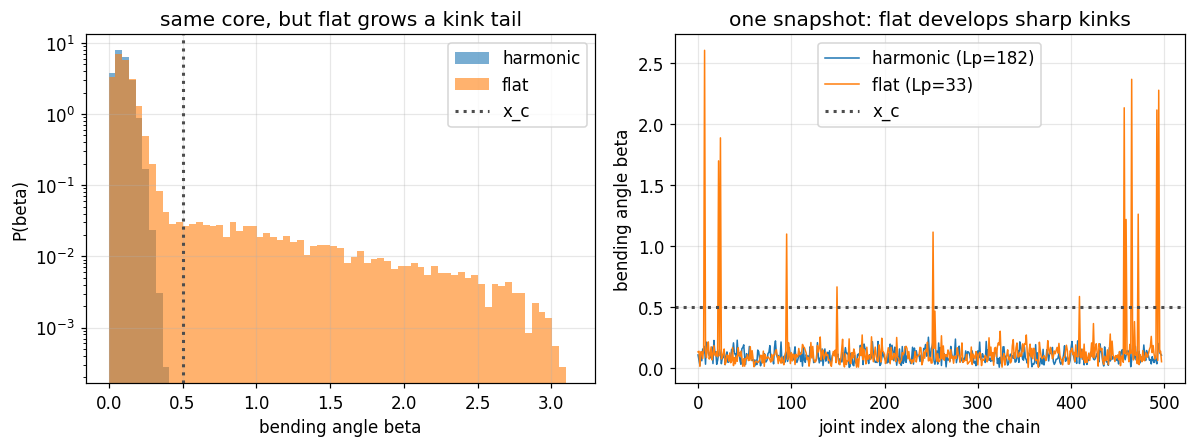

In [2]:
def random_fold(N, step=1.0, turn=0.10):
    """A *persistent* (worm-like) random walk: randomly folded but locally near-straight,
    so both chains start close to the stiff harmonic equilibrium and relax quickly.
    Uses polykit's generator when available, else an inline equivalent."""
    try:
        from polykit.generators.initial_conformations import create_constrained_random_walk
        p = create_constrained_random_walk(N, lambda x: True, step_size=step, polar_fixed=turn)
    except Exception:
        rng = np.random.default_rng(0)
        d = np.zeros((N, 3)); d[0] = [1, 0, 0]
        for i in range(1, N):
            perp = np.cross(d[i - 1], rng.normal(size=3)); perp /= np.linalg.norm(perp)
            d[i] = np.cos(turn) * d[i - 1] + np.sin(turn) * perp
        p = np.cumsum(step * d, axis=0)
    p = np.asarray(p); return p - p.mean(axis=0)


def kink_run(make_angle, N=500, k_bond=300.0, kT=1.0, dt=0.005,
             equil=80000, prod=80000, every=500):
    """Semiflexible phantom chain from a random fold; return bending angles, Lp, a profile."""
    pos = random_fold(N)
    L = 2.0 * float(np.abs(pos).max()) + 30.0
    snap = hoomd.Snapshot(dev.communicator)
    if snap.communicator.rank == 0:
        snap.configuration.box = [L, L, L, 0, 0, 0]
        snap.particles.N = N; snap.particles.types = ["A"]; snap.particles.mass[:] = 1.0
        snap.particles.position[:] = pos
        b = np.column_stack([np.arange(N - 1), np.arange(1, N)])
        snap.bonds.N = len(b); snap.bonds.types = ["A-A"]; snap.bonds.group[:] = b
        a = np.column_stack([np.arange(N - 2), np.arange(1, N - 1), np.arange(2, N)])
        snap.angles.N = len(a); snap.angles.types = ["A-A-A"]; snap.angles.group[:] = a
    sim = hoomd.Simulation(device=dev, seed=7)
    sim.create_state_from_snapshot(snap)
    bond = hoomd.md.bond.Harmonic(); bond.params["A-A"] = dict(k=k_bond, r0=1.0)
    lang = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=kT)
    integ = hoomd.md.Integrator(dt=dt, methods=[lang], forces=[bond, make_angle()])
    sim.operations.integrator = integ
    for wdt, wsteps in [(1e-4, 5000), (1e-3, 5000), (dt, 10000)]:   # relax the sharp initial folds
        integ.dt = wdt; sim.run(wsteps)
    integ.dt = dt
    sim.run(equil)

    def bending(p):
        u = p[1:] - p[:-1]; u /= np.linalg.norm(u, axis=1, keepdims=True)
        return np.arccos(np.einsum("ij,ij->i", u[:-1], u[1:]).clip(-1, 1))

    betas = []
    for _ in range(prod // every):
        sim.run(every)
        betas.append(bending(positions_by_tag(sim)))
    Lp = -1.0 / np.log(np.cos(np.concatenate(betas)).mean())   # bond length b = 1
    return np.concatenate(betas), Lp, betas[-1]                 # last snapshot's profile


def _set(force, params):
    force.params["A-A-A"] = params; return force


K, XC = 180.0, 0.5
bh, Lph, profh = kink_run(lambda: _set(hoomd.md.angle.Harmonic(), dict(k=K, t0=np.pi)))
bf, Lpf, proff = kink_run(lambda: _set(align_angle.SoftHarmonicAngle(),
                                       dict(k=K, t0=np.pi, x_c=XC, tail="flat")))
print(f"plateau energy = k*x_c^2/6 = {K*XC**2/6:.1f} kT   (bends past x_c cost <= this)")
print(f"harmonic:  Lp = {Lph:6.1f} b,   kinks (beta > x_c) = {np.mean(bh>XC):.2%}")
print(f"flat:      Lp = {Lpf:6.1f} b,   kinks (beta > x_c) = {np.mean(bf>XC):.2%}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
bins = np.linspace(0, np.pi, 70)
a1.hist(bh, bins=bins, density=True, alpha=0.6, label="harmonic")
a1.hist(bf, bins=bins, density=True, alpha=0.6, label="flat")
a1.axvline(XC, color="0.3", ls=":", label="x_c")
a1.set_yscale("log"); a1.set_xlabel("bending angle beta"); a1.set_ylabel("P(beta)")
a1.set_title("same core, but flat grows a kink tail"); a1.legend()

a2.plot(np.arange(len(profh)), profh, lw=1.0, label=f"harmonic (Lp={Lph:.0f})")
a2.plot(np.arange(len(proff)), proff, lw=1.0, label=f"flat (Lp={Lpf:.0f})")
a2.axhline(XC, color="0.3", ls=":", label="x_c")
a2.set_xlabel("joint index along the chain"); a2.set_ylabel("bending angle beta")
a2.set_title("one snapshot: flat develops sharp kinks"); a2.legend()
fig.tight_layout(); plt.show()

## 2. Breakable vs ductile bond (flat vs linear)

Anchor one end of a short chain and pull the other with a steadily increasing force `F`
(`hoomd.md.force.Constant` on a dedicated end type), recording the end-to-end extension.
The single-bond force peaks at the **rupture force** `F* ≈ 0.286·k·x_c` (max of
`k·x·(1-(x/x_c)²)²`) and the linear cap is at `k·x_c`.

* **flat** — extension runs away once `F` reaches the rupture force: the chain **snaps**
  (brittle).
* **linear** — sustains load up to the `k·x_c` yield, then flows (ductile).
* **harmonic** — extends elastically, never fails.

Note the window between the two thresholds where the linear chain still holds a load that
has already severed the flat one.

rupture force F* = 5.7   linear yield k*x_c = 20


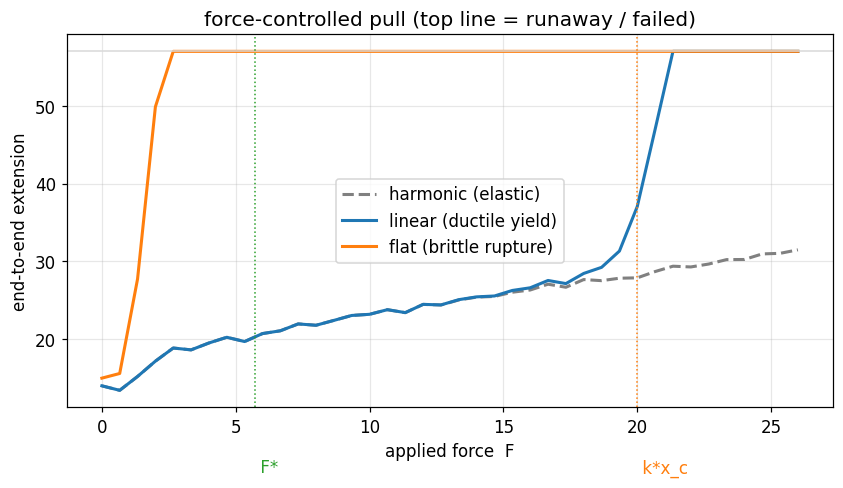

In [3]:
def _setb(force, params):
    force.params["A-A"] = params; return force


def pull(make_bond, F_values, N=20, r0=1.0, kT=0.3, dt=0.005,
         equil=2500, nsamp=20, sample_every=100):
    """Anchor bead 0, pull bead N-1 (type 'E') with force F; return extension R(F)."""
    L = 1.0e5
    snap = hoomd.Snapshot(dev.communicator)
    if snap.communicator.rank == 0:
        snap.configuration.box = [L, L, L, 0, 0, 0]
        snap.particles.N = N; snap.particles.types = ["A", "E"]; snap.particles.mass[:] = 1.0
        p = np.zeros((N, 3)); p[:, 0] = np.arange(N) - (N - 1) / 2
        snap.particles.position[:] = p
        tid = np.zeros(N, dtype=int); tid[N - 1] = 1; snap.particles.typeid[:] = tid
        b = np.column_stack([np.arange(N - 1), np.arange(1, N)])
        snap.bonds.N = len(b); snap.bonds.types = ["A-A"]; snap.bonds.group[:] = b
    sim = hoomd.Simulation(device=dev, seed=3)
    sim.create_state_from_snapshot(snap)
    bond = make_bond()
    pull_f = hoomd.md.force.Constant(filter=hoomd.filter.All())
    pull_f.constant_force["A"] = (0, 0, 0); pull_f.constant_force["E"] = (0, 0, 0)
    mobile = hoomd.filter.SetDifference(hoomd.filter.All(), hoomd.filter.Tags([0]))
    lang = hoomd.md.methods.Langevin(filter=mobile, kT=kT)
    sim.operations.integrator = hoomd.md.Integrator(dt=dt, methods=[lang], forces=[bond, pull_f])
    sim.run(0)
    R = []
    for F in F_values:
        pull_f.constant_force["E"] = (F, 0, 0)
        sim.run(equil)
        rr = []
        for _ in range(nsamp):
            sim.run(sample_every)
            p = positions_by_tag(sim); rr.append(p[-1, 0] - p[0, 0])
        R.append(np.mean(rr))
    return np.array(R)


K, XC = 40.0, 0.5
Frup, Fyield = 16.0 / (25 * np.sqrt(5)) * K * XC, K * XC
F = np.linspace(0, 26, 40)
Rh = pull(lambda: _setb(hoomd.md.bond.Harmonic(), dict(k=K, r0=1.0)), F)
Rl = pull(lambda: _setb(align_angle.SoftHarmonic(), dict(k=K, r0=1.0, x_c=XC, tail="linear")), F)
Rf = pull(lambda: _setb(align_angle.SoftHarmonic(), dict(k=K, r0=1.0, x_c=XC, tail="flat")), F)
print(f"rupture force F* = {Frup:.1f}   linear yield k*x_c = {Fyield:.0f}")

Rc = 3 * (N_nat := 19.0)
clip = lambda R: np.clip(R, 0, Rc)
fig, ax = plt.subplots(figsize=(7.8, 4.6))
ax.plot(F, clip(Rh), "--", color="0.5", label="harmonic (elastic)")
ax.plot(F, clip(Rl), label="linear (ductile yield)")
ax.plot(F, clip(Rf), label="flat (brittle rupture)")
ax.axhline(Rc, color="0.85", lw=1)
ax.axvline(Frup, color="C2", ls=":", lw=1); ax.axvline(Fyield, color="C1", ls=":", lw=1)
ax.text(Frup, Rc * 0.05, " F*", color="C2"); ax.text(Fyield, Rc * 0.05, " k*x_c", color="C1")
ax.set_xlabel("applied force  F"); ax.set_ylabel("end-to-end extension")
ax.set_title("force-controlled pull (top line = runaway / failed)"); ax.legend()
fig.tight_layout(); plt.show()

## 3. Timestep stability (linear bond)

A plain harmonic bond is linear, so its integration is stable only for
`dt < ~2/√k` regardless of how far it is stretched. The **linear** tail is *flat* beyond
`x_c` — zero curvature — so bonds held in the tail impose **no** stiff timescale. We hold
a chain taut (both ends fixed at 60% strain, so every bond sits in the tail) and sweep
`dt`: the harmonic chain blows up at the usual limit, the capped chain survives several
times larger `dt`.

max stable dt:  harmonic = 0.06,  SoftHarmonic linear = 0.18   (3x)


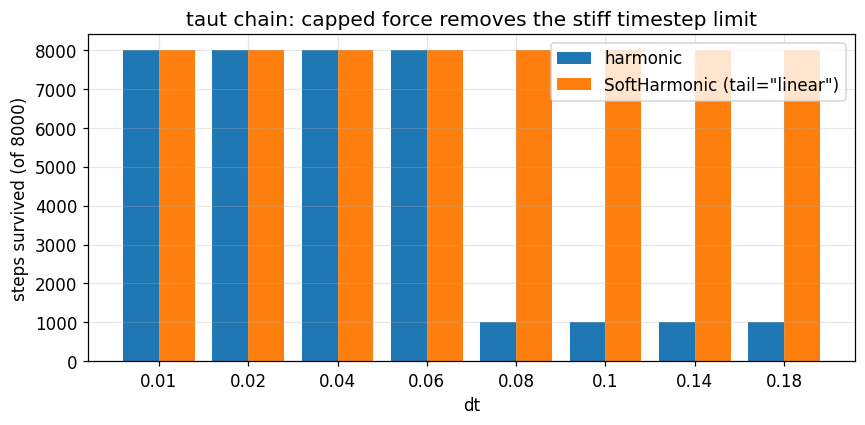

In [4]:
def stable_to(make_bond, dt, N=40, strain=0.6, kT=1.0, n_steps=8000, chunk=1000):
    """Held-taut chain (ends fixed); return steps survived before blow-up (or n_steps)."""
    try:
        L = 400.0; d = (N - 1) * (1 + strain)
        snap = hoomd.Snapshot(dev.communicator)
        if snap.communicator.rank == 0:
            snap.configuration.box = [L, L, L, 0, 0, 0]
            snap.particles.N = N; snap.particles.types = ["A"]; snap.particles.mass[:] = 1.0
            p = np.zeros((N, 3)); p[:, 0] = np.linspace(-d / 2, d / 2, N)
            snap.particles.position[:] = p
            b = np.column_stack([np.arange(N - 1), np.arange(1, N)])
            snap.bonds.N = len(b); snap.bonds.types = ["A-A"]; snap.bonds.group[:] = b
        sim = hoomd.Simulation(device=dev, seed=123)
        sim.create_state_from_snapshot(snap)
        bond = make_bond()
        mobile = hoomd.filter.SetDifference(hoomd.filter.All(), hoomd.filter.Tags([0, N - 1]))
        lang = hoomd.md.methods.Langevin(filter=mobile, kT=kT)
        sim.operations.integrator = hoomd.md.Integrator(dt=dt, methods=[lang], forces=[bond])
        thermo = hoomd.md.compute.ThermodynamicQuantities(filter=mobile)
        sim.operations.computes.append(thermo)
        done = 0
        for _ in range(n_steps // chunk):
            sim.run(chunk); done += chunk
            ke = thermo.kinetic_energy
            fin = np.all(np.isfinite(np.array(sim.state.get_snapshot().particles.position)))
            if not (np.isfinite(ke) and ke / N < 1e6 and fin):
                return done
        return n_steps
    except Exception:
        return 0


K, XC = 200.0, 0.3
dts = [0.01, 0.02, 0.04, 0.06, 0.08, 0.1, 0.14, 0.18]
sh = [stable_to(lambda: _setb(hoomd.md.bond.Harmonic(), dict(k=K, r0=1.0)), dt) for dt in dts]
sl = [stable_to(lambda: _setb(align_angle.SoftHarmonic(), dict(k=K, r0=1.0, x_c=XC, tail="linear")), dt) for dt in dts]
maxh = max([dt for dt, s in zip(dts, sh) if s == 8000], default=0)
maxl = max([dt for dt, s in zip(dts, sl) if s == 8000], default=0)
print(f"max stable dt:  harmonic = {maxh},  SoftHarmonic linear = {maxl}   ({maxl/maxh:.0f}x)")

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(dts)); w = 0.4
ax.bar(x - w/2, sh, w, label="harmonic")
ax.bar(x + w/2, sl, w, label='SoftHarmonic (tail="linear")')
ax.set_xticks(x); ax.set_xticklabels([str(d) for d in dts])
ax.set_xlabel("dt"); ax.set_ylabel("steps survived (of 8000)")
ax.set_title("taut chain: capped force removes the stiff timestep limit"); ax.legend()
fig.tight_layout(); plt.show()

**Takeaways**

* **Flat angle → kinks.** Identical local stiffness, yet allowing bends past `x_c` to
  saturate turns a near-rigid rod into a kinked coil — a heavy-tailed `P(β)` and an
  order-of-magnitude shorter persistence length. (Relevant to chromatin/DNA kinking.)
* **Flat vs linear bond → brittle vs ductile.** The flat tail gives a finite rupture
  force (breakable/sacrificial bonds); the linear tail yields at a constant force without
  breaking (a tough, capped bond).
* **Linear tail → stability.** Capping the force removes the stiff timescale of taut
  bonds, allowing several-fold larger time steps than a plain harmonic bond.